In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path
base_path = Path('/content/drive/MyDrive/przetwarzanie_wizualizacja_danych')

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(base_path / 'titanic.csv', index_col= 'PassengerId')

In [5]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.Survived.value_counts(normalize = True).round(2)

,proportion
Survived,
0,0.62
1,0.38


Dataset jest lekko niezbalansowany

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      793 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


W kolumnach 'Age', 'Fare', 'Cabin', 'Embarked' są brakujące wartości.
Typ float dla kolumny 'Age' sugeruje obecność liczb niecałkowitych.

In [8]:
def get_percentage_missing(df, axis):
  missing_rows = df.isna().sum(axis = axis)
  missing_rows_perc = np.round(missing_rows / df.shape[axis] * 100, 2)
  return missing_rows_perc[missing_rows_perc > 0]

In [9]:
get_percentage_missing(df, axis = 0)

,0
Age,19.87
Fare,11.00
Cabin,77.10
Embarked,0.22


Kolumna 'Cabin' prawie w całości składa się z brakujących wartości

In [10]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,793.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,33.123938
std,0.486592,0.836071,14.526497,1.102743,0.806057,51.578312
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.925000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.500000
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.275000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Minimalny wiek (0.42) oraz pierwszy kwartyl (20.125) nie są liczbami całkowitymi. Prawdopodobnie, że wiek uwzględnia też miesiąc.

Dane w kolumnie 'Fare' są sensowne.
Historyczne ceny biletów Titanica: około 7 funtów dla klasy trzeciej, około 12 dla klasy drugiej, od 30 wzwyż dla klasy pierwszej, wartości równe 0 oznaczają bilety służbowe

# Uzupełnianie wartości brakujących

In [11]:
def histogram(df, col):

  plt.figure(figsize = (8,4))
  plt.hist(df[col], bins = 80, color = 'lightblue', edgecolor='black')
  plt.title(f'{col} distribution')
  plt.xlabel(col)
  plt.ylabel('Frequency')
  plt.show()

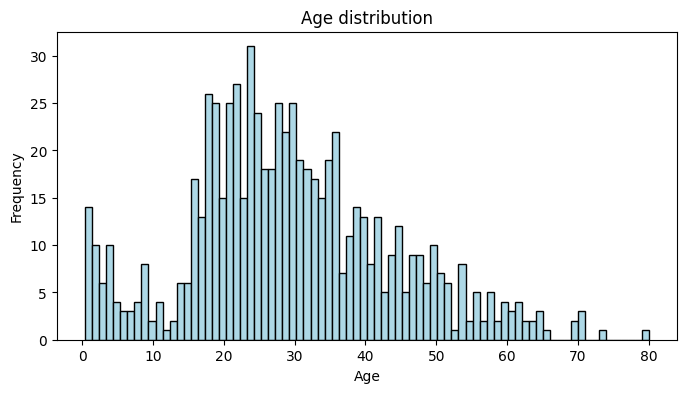

In [12]:
histogram(df, 'Age')

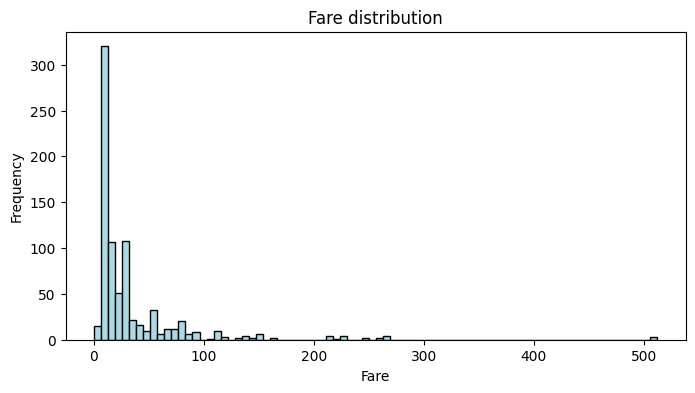

In [13]:
histogram(df, 'Fare')

Uzupełniam braki danych w kolumnach 'Age' i 'Fare' zgodnie rozkładu istniejących danych

In [14]:
def get_column_distribution(df, column):
  return df[column].value_counts(normalize = True)

In [15]:
def missing_vals_imputation(df, col):
  df_dist = get_column_distribution(df, col)

  df_values = df_dist.index
  df_probs = df_dist.values

  missing_df_col_values = df[col].isna()
  df.loc[missing_df_col_values, col] = np.random.choice(df_values, size = missing_df_col_values.sum(), p= df_probs)

  return df[col].isna().sum()

In [16]:
missing_vals_imputation(df, 'Age')

np.int64(0)

Rozkład cen za bilet różni się w zależności od klasy, dlatego uzupełniam brakujące dane dla każdej klasy osobno

In [17]:
def missing_vals_for_classes(df, column):

  first_class_df = df[df['Pclass'] == 1]
  second_class_df = df[df['Pclass'] == 2]
  third_class_df = df[df['Pclass'] == 3]

  print(missing_vals_imputation(first_class_df, column))
  print(missing_vals_imputation(second_class_df, column))
  print(missing_vals_imputation(third_class_df, column))

  df = pd.concat([first_class_df, second_class_df, third_class_df]).sort_index()

  return df

In [18]:
df = missing_vals_for_classes(df, 'Fare')

0
0
0


In [19]:
df.describe(include = 'object')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


In [20]:
df['Ticket'].duplicated().sum()

np.int64(210)

210 osób posiadało współne bilety. Osoby z pierwszej i drugiej klasy z tym samym numerem biletu były zakwaterowane obok siebie. Osoby z trzeciej klasy były rozdzielane niezależnie od numeru biletu.

In [21]:
print(df['Cabin'].str[0].unique())

df['Deck'] = df['Cabin'].str[0]
df = df.drop(columns = ['Cabin'])

[nan 'C' 'E' 'G' 'D' 'A' 'B' 'F' 'T']


Zmienna 'Deck' (pokład) redukuje wymiarowość oraz ułatwia uzupełnianie brakujących wartości ze względu na ogólność.

Uzupełniam pokłady zgodnie z numerem biletu dla osób z pierwszej i drugiej klasy.

In [22]:
df['Ticket'] = df['Ticket'].str.strip()

In [23]:
is_ticket_duplicated = df.Ticket.duplicated()
ticket_duplicates = df.loc[is_ticket_duplicated, 'Ticket'].unique()

In [24]:
same_ticket = df[(df['Ticket'].isin(ticket_duplicates)) & ((df['Pclass'] == 1) | (df['Pclass'] == 2))]
same_ticket.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck
PassengerId,,,,,,,,,,,
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,C
10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C,NaN
21,0,2,"Fynney, Mr. Joseph J",male,35.0,0,0,239865,26.0000,S,NaN
28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,S,C
32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,25.0,1,0,PC 17569,146.5208,C,B


In [25]:
def get_cabins(df, ticket_duplicates):

  for t in ticket_duplicates:
    for k in df.Deck.dropna().unique():
      if ((df['Ticket'] == t) & (df['Deck'] == k)).any():
        df.loc[(df['Ticket'] == t) & (df['Deck'].isna()), 'Deck'] = k
  return df

In [26]:
print(f'Braki danych przed funkcją: {same_ticket['Deck'].isna().sum()}')
same_ticket = get_cabins(same_ticket, ticket_duplicates)
print(f'Braki danych teraz: {same_ticket['Deck'].isna().sum()}')

Braki danych przed funkcją: 88
Braki danych teraz: 78


In [27]:
df.loc[(df['Ticket'].isin(ticket_duplicates)) & ((df['Pclass'] == 1) | (df['Pclass'] == 2)), 'Deck'] = same_ticket['Deck']

In [28]:
df.groupby('Pclass')['Deck'].value_counts()

Pclass  Deck
1       C       67
        B       48
        D       29
        E       25
        A       15
        T        1
2       F        8
        E        5
        D        4
3       F        5
        G        4
        E        3
Name: count, dtype: int64

Każda klasa była przypisana do określonych pokładów, dlatego uzupełnienie braków zgodnie z ogólnym rozkładem danych może zaburzyć wynik. Na przykład, przypisać osobę z klasy 3 do pokładu na którym są tylko osoby z klasy 1 lub 2. Dlatego uzupełniam dane dla każdej klasy osobno

In [29]:
df = missing_vals_for_classes(df, 'Deck')

0
0
0


In [30]:
df['Deck'] = df['Deck'].astype(pd.CategoricalDtype(categories=['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T'], ordered=True))

In [31]:
get_column_distribution(df, 'Embarked')

,proportion
Embarked,
S,0.724409
C,0.188976
Q,0.086614


In [32]:
df.Embarked.isna().sum()

np.int64(2)

Tworzenie sztucznej kategorii dla dwóch braków się nie opłaca oraz kolumna posiada dominującą wartość S, dlatego optymalnym rozwiązaniem jest uzupełnienie tych braków najczęstszą wartością

In [33]:
df.Embarked = df.Embarked.fillna('S')
df.Embarked.isna().sum()

np.int64(0)

# Feature Engineering

Historycznie, osoby z różnych klas były rozmieszczane w określonych częściach statku. Klasa pierwsza zajmowała środek, klasa druga była przesunięta ku rufie, a osoby z klasy trzeciej były dzielone na samotnych mężczyzn na dziobie oraz rodziny i kobiety na rufie. Ze względu na ten podział można utworzyć nową cechę 'Section'.

In [34]:
pclass_3_male_alone = df[(df['Pclass'] == 3) & (df['Parch'] == 0) & (df['Sex'] == 'male')]
pclass_3_male_alone.head(2)


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,S,G
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,S,F


In [35]:
pclass_3_other = df[(df['Pclass'] == 3) & ~(df.index.isin(pclass_3_male_alone.index))]
pclass_3_other.head(2)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck
PassengerId,,,,,,,,,,,
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.925,S,E
8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.075,S,F


In [36]:
pclass_1 = df[(df['Pclass'] == 1)]
pclass_1.head(2)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck
PassengerId,,,,,,,,,,,
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,C


In [37]:
df['Section'] = np.nan

for i in df.index:
  if i in pclass_3_male_alone.index:
    df.loc[i, 'Section'] = 'bow'
  elif i in pclass_3_other.index:
    df.loc[i, 'Section'] = 'stern'
  elif i in pclass_1.index:
    df.loc[i, 'Section'] = 'midship'
  else:
    df.loc[i, 'Section'] = 'midship_aft'

/tmp/ipykernel_1203/2161268867.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'bow' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[i, 'Section'] = 'bow'


Ceny biletów w klasie pierwszej są mocno zróżnicowane, co świadczy o różnym poziomie zamożności osób. Minimalny koszt wejścia do klasy pierwszej wynosił 30 funtów, jednak w danych pojawiają się o wiele większe kwoty np. 200 funtów. Nowa cecha "Wealth_level" będzie wskazywać poziom zamożności wszystkich osób.

Również, kolumna 'Fare' oznacza łączną cenę za bilet dla grupy. Dlatego, aby poprawnie wskazać poziom zamożności osób, obliczam przy duplikatach cenę na osobę.

In [38]:
people_on_ticket = df[df['Ticket'].isin(ticket_duplicates)]['Ticket'].value_counts()

df['People_On_Ticket'] = df['Ticket'].map(people_on_ticket)
df['People_On_Ticket'] = df['People_On_Ticket'].fillna(1)

df['People_On_Ticket'] = df['People_On_Ticket'].astype('int')

df['People_On_Ticket'].value_counts()

,count
People_On_Ticket,
1,547
2,188
3,63
4,44
7,21
6,18
5,10


In [39]:
df['Fare_per_person'] = df['Fare'] / df['People_On_Ticket']
df = df.drop(columns = ['Fare', 'People_On_Ticket'])

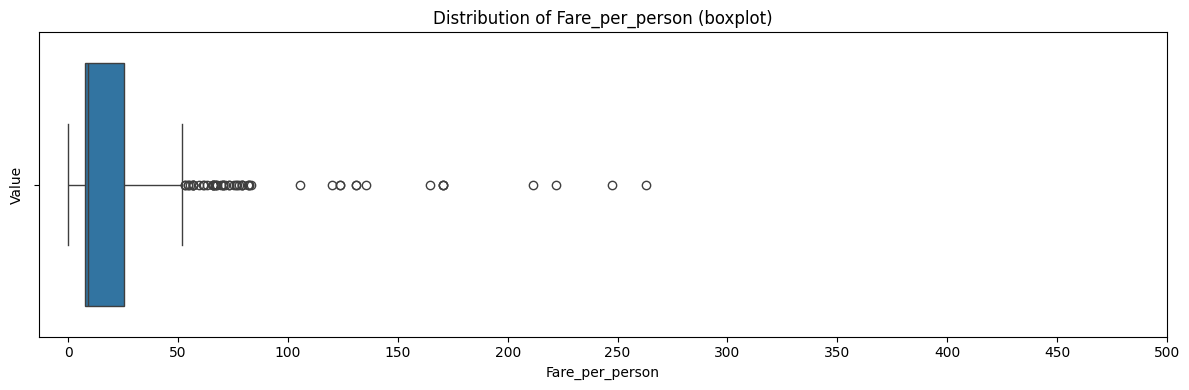

In [40]:
plt.figure(figsize=(12,4))
sns.boxplot(data = df, x = 'Fare_per_person')
plt.title(f"Distribution of Fare_per_person (boxplot)")
plt.ylabel("Value")
plt.xticks(np.arange(0, 550, step=50))
plt.tight_layout()
plt.show()

In [41]:
Q1 = df['Fare_per_person'].quantile(0.25)
Q3 = df['Fare_per_person'].quantile(0.75)
IQR = Q3-Q1
upper_bound = Q3 + (1.5 * IQR)
round(upper_bound, 2)

np.float64(52.33)

Większość osób bogatych 'upper_class' mieści się w przedziale od 30 do 53.23 funta. Powyżej są wartości odstające, przy czym są rozdzielone pustymi przedziałami w danych. Kwota 200 funtów znajduje się wewnątrz takiej luki, oraz po tej kwocie znajdują się najbardziej ekstremalne wartości. Dlatego 200 jest dobrą granicą między kategorią 'wealthy' (od 53.23 do 200) a 'elite'.

In [42]:
for i in df.index:
  if df.loc[i, 'Fare_per_person'] >= 200:
    df.loc[i, 'Wealth_level'] = 'elite'
  elif (df.loc[i, 'Fare_per_person'] >= 53.23) & (df.loc[i, 'Fare_per_person'] < 200):
    df.loc[i, 'Wealth_level'] = 'wealthy'
  elif (df.loc[i, 'Fare_per_person'] >= 30) & (df.loc[i, 'Fare_per_person'] < 53.23):
    df.loc[i, 'Wealth_level'] = 'upper_class'
  elif (df.loc[i, 'Fare_per_person'] >= 12) & (df.loc[i, 'Fare_per_person'] < 30):
    df.loc[i, 'Wealth_level'] = 'middle_class'
  else:
    df.loc[i, 'Wealth_level'] = 'lower_class'

In [43]:
df['Wealth_level'] = df['Wealth_level'].astype(pd.CategoricalDtype(categories=['lower_class', 'middle_class', 'upper_class', 'wealthy', 'elite'], ordered=True))

Zmienne 'SibSp' i 'Parch' informują o liczbie członków rodziny, dlatego łączę je w cechę 'Family_size' oraz dodaję 1, aby uwzględnić samego pasażera

In [44]:
df['Family_size'] = df['SibSp'] + df['Parch'] + 1
df = df.drop(columns = ['SibSp', 'Parch'])

In [45]:
df.head(2)

,Survived,Pclass,Name,Sex,Age,Ticket,Embarked,Deck,Section,Fare_per_person,Wealth_level,Family_size
PassengerId,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,A/5 21171,S,G,bow,7.2500,lower_class,2
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,PC 17599,C,C,midship,71.2833,wealthy,2


# Wizualizacja danych

In [46]:
numerical_cols = df.select_dtypes('number')

In [47]:
categorical_cols = df.select_dtypes(['object','category'])
categorical_cols = categorical_cols.drop(columns = ['Name', 'Ticket'])

In [48]:
def boxplots(df):

  fig, axis = plt.subplots(2, 3, figsize=(15, 10))
  axis = axis.flatten()

  for i, col in enumerate(df.columns):
    sns.boxplot(x=df[col], ax = axis[i], color='lightblue', linecolor="black")
    axis[i].set_xlabel(col)

  plt.tight_layout()
  plt.show()

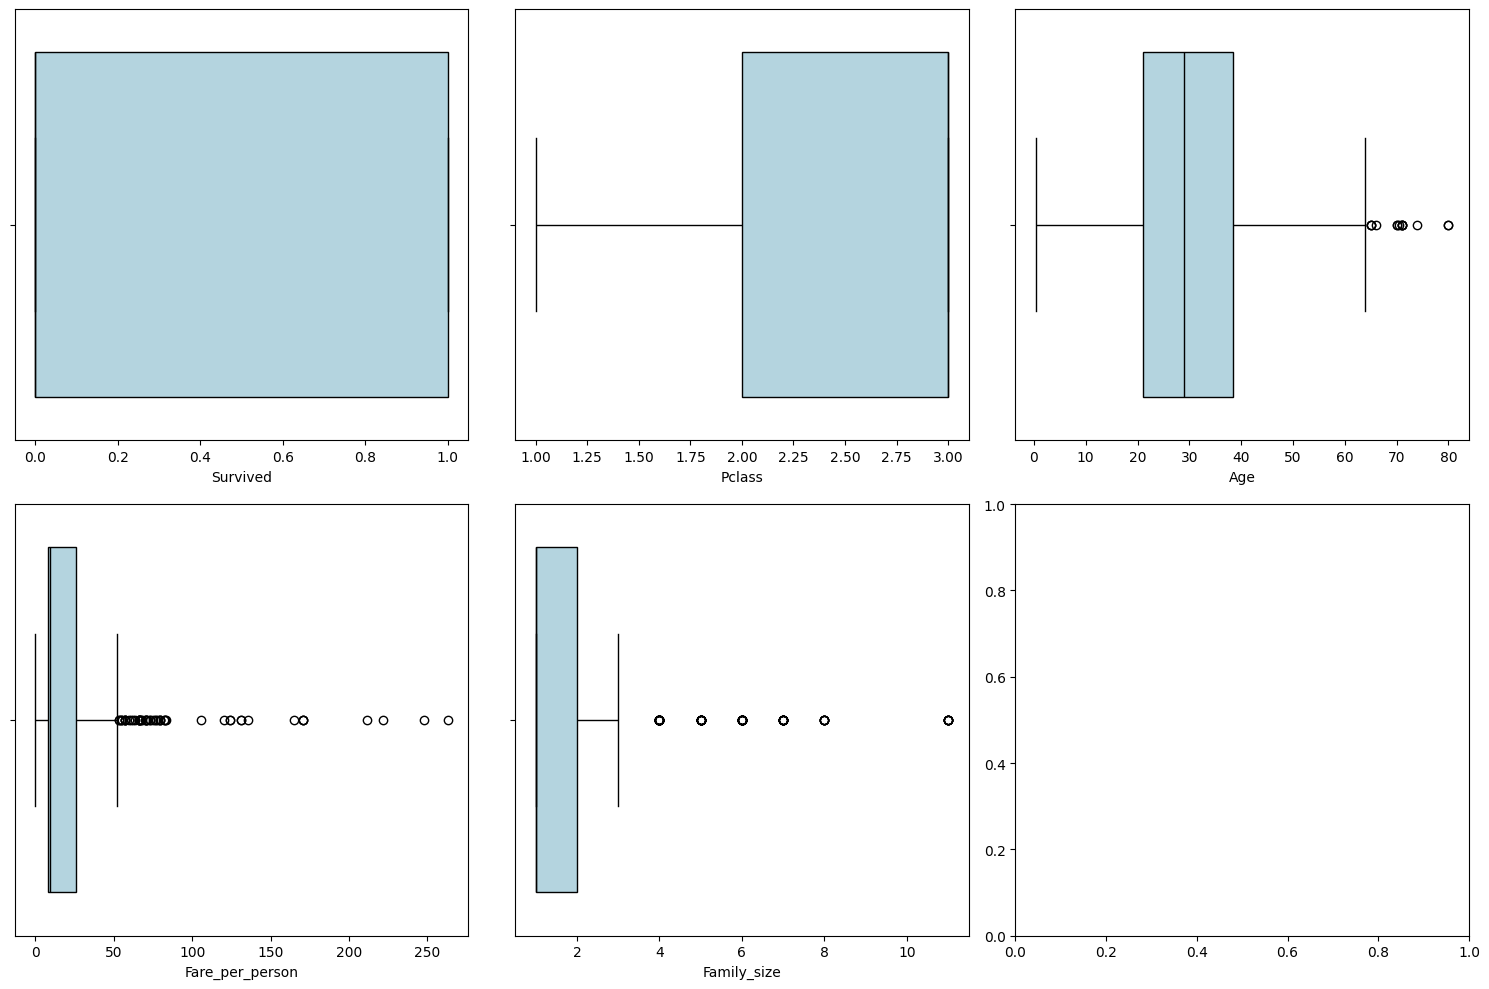

In [49]:
boxplots(numerical_cols)

Ważne jest pozostawienie informacji o cenach biletów, nawet tych odstających. Pozostałe zmienne również nie wymagają usuwania wartości odstających.

In [50]:
def barplots(df, y):
  fig, axis = plt.subplots((len(df.columns) + 1) // 2, 2, figsize=(10, 10))
  axis = axis.flatten()

  for i, col in enumerate(df.columns):
      sns.barplot(x=df[col], y=y, data=df, ax=axis[i], edgecolor='black', errorbar=None, color = 'lightblue')
      axis[i].set_title(f'Survival Rate by {col.capitalize()}')
      axis[i].set_xlabel(col.capitalize())
      axis[i].set_ylabel('Survival Rate')

  plt.tight_layout()
  plt.show()

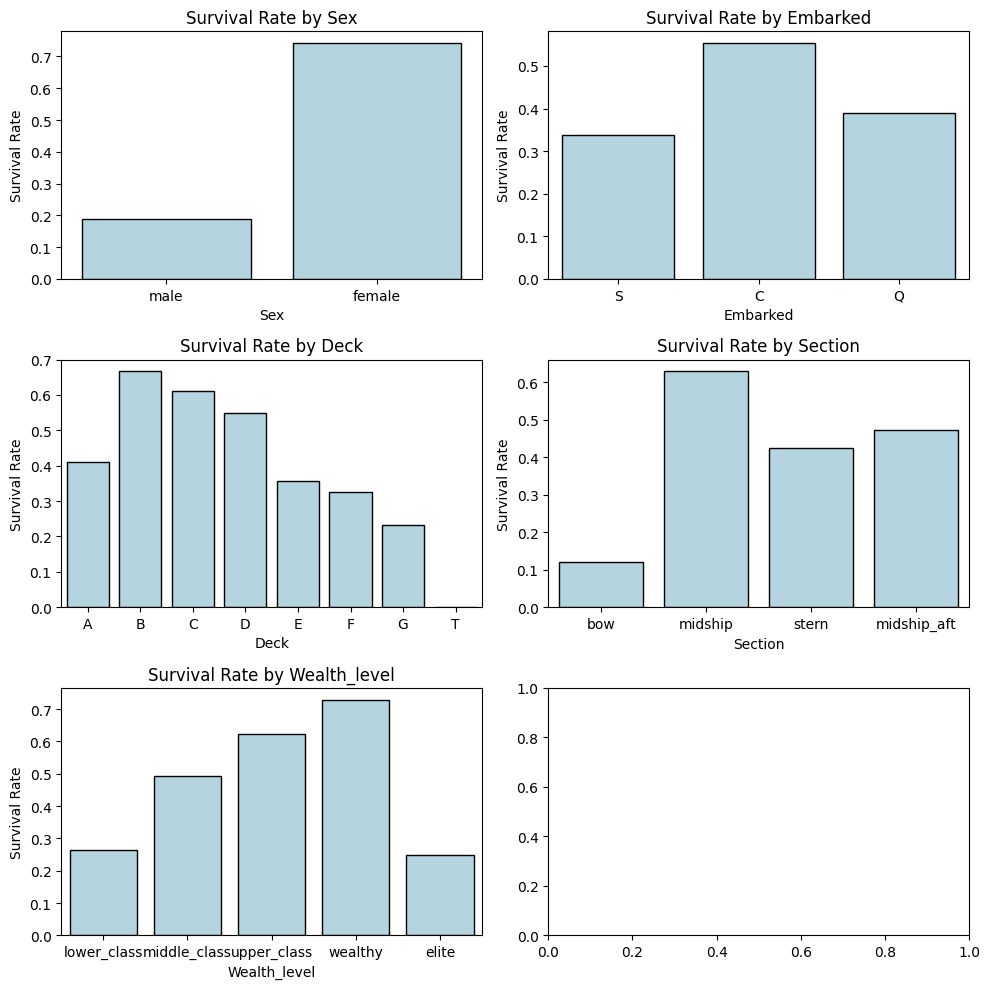

In [51]:
barplots(categorical_cols, df['Survived'])

Dzięki wykresom widać, że większe szanse na przeżycie miały kobiety, osoby zamożne, osoby ulokowane na wyższych pokładach i w środkowej części statku.

Najmniejsze szanse mieli mężczyźni, osoby uboższe oraz osoby ulokowane na dolnych pokładach i na dziobie statku.

In [52]:
numerical_cols['Age'] = pd.cut(numerical_cols['Age'], bins=4, labels=['0-20', '20-40', '40-60', '60-80'])

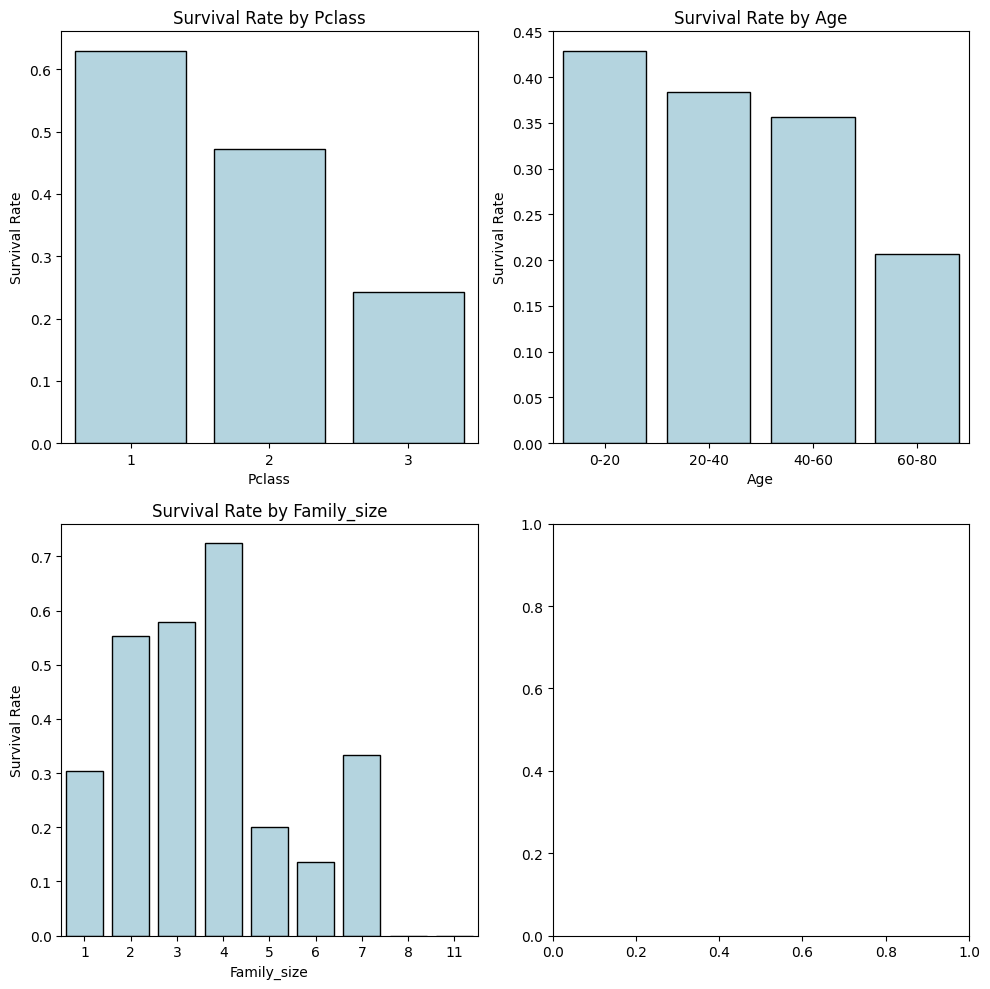

In [53]:
barplots(numerical_cols.drop(columns = ['Survived', 'Fare_per_person']), df['Survived'])

Najmniejsze szanse na przeżycie miały osoby należące do trzeciej klasy, osoby w wieku od 60 do 80 lat, członkowie dużych rodzin, osoby samotne

# Kodowanie kolumn

In [54]:
X = df.copy()
X = X.drop(columns = ['Survived', 'Name', 'Ticket'])

In [55]:
y = df['Survived']

In [56]:
X.head()

,Pclass,Sex,Age,Embarked,Deck,Section,Fare_per_person,Wealth_level,Family_size
PassengerId,,,,,,,,,
1,3,male,22.0,S,G,bow,7.2500,lower_class,2
2,1,female,38.0,C,C,midship,71.2833,wealthy,2
3,3,female,26.0,S,E,stern,7.9250,lower_class,1
4,1,female,35.0,S,C,midship,26.5500,middle_class,2
5,3,male,35.0,S,F,bow,8.0500,lower_class,1


Binarne kodowanie dla zmiennej 'Sex':

In [57]:
mapping = {
    'male' : 1,
    'female' : 0
}

X['Is_Male'] = X['Sex'].map(mapping)
X = X.drop(columns = 'Sex')

One_hot_encoding dla pozostałych zmiennych nominalnych:

In [58]:
def one_hot_encoding(df, col):
  one_hot_encoded = pd.get_dummies(data = df, prefix = col, columns = [col], dtype = np.int32)
  return one_hot_encoded


In [59]:
X = one_hot_encoding(X, 'Section')
X = one_hot_encoding(X, 'Embarked')

Ordinal encoding dla zmiennych porządkowych:

In [60]:
mapping = {
    'elite': 1,
    'wealthy': 2,
    'upper_class': 3,
    'middle_class': 4,
    'lower_class': 5,
}

X['Wealth_level'] = X['Wealth_level'].map(mapping)

In [61]:
labels_mapping = {
    k: i for i, k in enumerate(sorted(X['Deck'].unique()))
}

X['Deck'] = X.Deck.map(labels_mapping)

In [62]:
X.loc[X['Deck'] == 7, 'Deck'] = 0

Pokład numer 7 (po kodowaniu) to jest kabina 'T', która znajdowała się na samej górze

In [63]:
X.head(5)

,Pclass,Age,Deck,Fare_per_person,Wealth_level,Family_size,Is_Male,Section_bow,Section_midship,Section_midship_aft,Section_stern,Embarked_C,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,,,,
1,3,22.0,6,7.2500,5,2,1,1,0,0,0,0,0,1
2,1,38.0,2,71.2833,2,2,0,0,1,0,0,1,0,0
3,3,26.0,4,7.9250,5,1,0,0,0,0,1,0,0,1
4,1,35.0,2,26.5500,4,2,0,0,1,0,0,0,0,1
5,3,35.0,5,8.0500,5,1,1,1,0,0,0,0,0,1


# Zmiana zakresu wartości

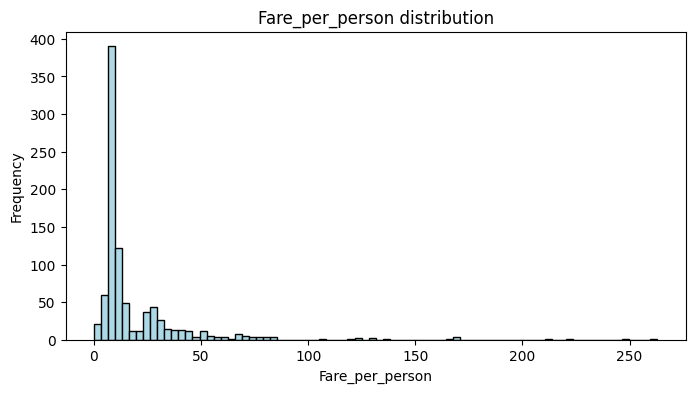

In [64]:
histogram(df, 'Fare_per_person')

Ze względu na to, że rozkład cen biletów ma wartości w zakresie od 0 do nieskończoności oraz jest prawoskośny, aby zmienić zakres wartości zmiennej stosuje się logarytmowanie

In [65]:
def logarytm(df, col):
  df[f'{col}_log'] = np.log1p(df[col])
  df = df.drop(columns = [col])
  return df

In [66]:
X = logarytm(X, 'Fare_per_person')

Kolumna 'Age' wymaga zmiany zakresu zmiennej ze względu na dużą różnice w skali w porównaniu do innych zmiennych

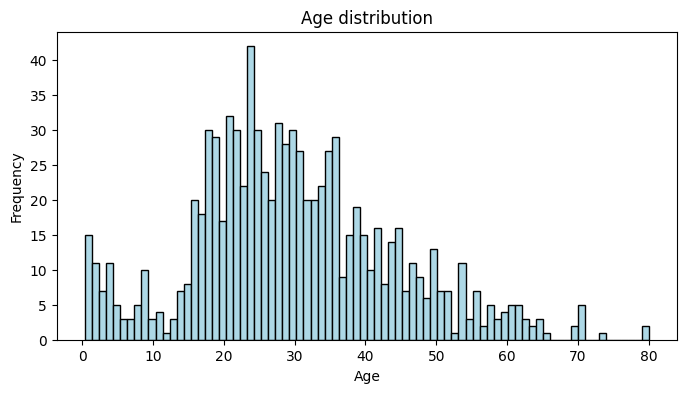

In [67]:
histogram(X, 'Age')

Rozkład prawoskośny, dlatego stosuję normalizację min-max a nie standaryzację

In [68]:
X['Age_normalized'] = (X['Age'] - X['Age'].min()) / (X['Age'].max() - X['Age'].min())

In [69]:
X = X.drop(columns = ['Age'])

# Wynik:

In [70]:
X.head()

,Pclass,Deck,Wealth_level,Family_size,Is_Male,Section_bow,Section_midship,Section_midship_aft,Section_stern,Embarked_C,Embarked_Q,Embarked_S,Fare_per_person_log,Age_normalized
PassengerId,,,,,,,,,,,,,,
1,3,6,5,2,1,1,0,0,0,0,0,1,2.110213,0.271174
2,1,2,2,2,0,0,1,0,0,1,0,0,4.280593,0.472229
3,3,4,5,1,0,0,0,0,1,0,0,1,2.188856,0.321438
4,1,2,4,2,0,0,1,0,0,0,0,1,3.316003,0.434531
5,3,5,5,1,1,1,0,0,0,0,0,1,2.202765,0.434531
